# Actividad Sesión 1 - Aprendizaje de Máquina No Supervisado
## Análisis de usuarios de música
Este notebook sigue las instrucciones para:
- Cargar y explorar datos.
- Limpiar y preprocesar.
- Aplicar K-Means.
- Reducir dimensionalidad con PCA.
- Detectar anomalías.
- Reflexionar sobre hallazgos.

In [11]:
# 1. Carga y exploración del dataset
import pandas as pd
import numpy as np

# Cargar dataset
df = pd.read_csv('usuarios_musica.csv')

# Mostrar primeras 5 filas
display(df.head())

# Resumen estadístico
display(df.describe())

,reproducciones_diarias,min_escucha_promedio,saltos_por_dia,artistas_distintos,dias_activo_mes,likes_dados,dispositivos_usados
0,28,3.78,6,30,30,11.0,3
1,34,2.88,5,4,29,6.0,1
2,23,3.29,2,8,14,5.0,1
3,32,3.01,3,11,12,8.0,1
4,36,2.91,5,35,28,8.0,1


,reproducciones_diarias,min_escucha_promedio,saltos_por_dia,artistas_distintos,dias_activo_mes,likes_dados,dispositivos_usados
count,150.000000,146.000000,150.000000,150.000000,150.00000,146.000000,150.000000
mean,29.913333,3.597260,4.926667,25.033333,16.82000,9.849315,1.993333
std,5.606727,0.923225,2.108139,13.819263,7.72086,3.225635,0.806822
min,13.000000,1.380000,1.000000,3.000000,5.00000,2.000000,1.000000
25%,26.000000,2.910000,3.000000,13.000000,10.00000,7.000000,1.000000
50%,30.000000,3.575000,5.000000,24.000000,16.00000,10.000000,2.000000
75%,33.000000,4.217500,6.000000,36.750000,23.75000,12.000000,3.000000
max,44.000000,5.690000,11.000000,49.000000,30.00000,18.000000,3.000000


Valores nulos por columna:
reproducciones_diarias    0
min_escucha_promedio      4
saltos_por_dia            0
artistas_distintos        0
dias_activo_mes           0
likes_dados               4
dispositivos_usados       0
dtype: int64


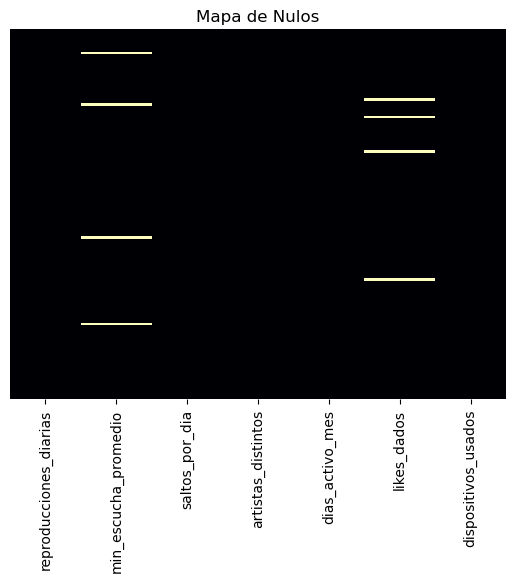

In [12]:
# 2. Limpieza y preprocesamiento
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt

# Verificar valores nulos
print('Valores nulos por columna:')
print(df.isnull().sum())

sns.heatmap(df.isnull(), cbar=False, cmap='magma', yticklabels=False)
plt.title('Mapa de Nulos')
plt.show()
# Imputar valores faltantes con la media (si existen)
df.fillna(df.mean(numeric_only=True), inplace=True)



In [3]:

# Normalizar datos numéricos
numeric_cols = df.select_dtypes(include=[np.number]).columns
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df[numeric_cols])
df_scaled = pd.DataFrame(df_scaled, columns=numeric_cols)
display (df_scaled.head())

,reproducciones_diarias,min_escucha_promedio,saltos_por_dia,artistas_distintos,dias_activo_mes,likes_dados,dispositivos_usados
0,-0.342400,0.201320,0.510843,0.360606,1.712783,0.362830,1.251873
1,0.731328,-0.790189,0.034902,-1.527129,1.582829,-1.213752,-1.235292
2,-1.237173,-0.338501,-1.392921,-1.236708,-0.366468,-1.529068,-1.235292
3,0.373419,-0.646971,-0.916980,-1.018893,-0.626374,-0.583119,-1.235292
4,1.089237,-0.757139,0.034902,0.723632,1.452876,-0.583119,-1.235292


In [4]:
# 3. Aplicación de K-Means para clusterización
from sklearn.cluster import KMeans

# Definir y ajustar modelo K-Means
kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster'] = kmeans.fit_predict(df_scaled)

print('Centroides:')
print(kmeans.cluster_centers_)
df.head()


Centroides:
[[ 0.02137677  0.21992216 -0.31620176  0.9640619  -0.2514274   0.3206978
   0.11022356]
 [ 0.15611665 -0.56973497 -0.2710598  -0.63857985  0.97019311 -0.14768237
   0.06750878]
 [-0.16725282  0.22369398  0.65261316 -0.68058345 -0.54066042 -0.28425333
  -0.20338311]]


,reproducciones_diarias,min_escucha_promedio,saltos_por_dia,artistas_distintos,dias_activo_mes,likes_dados,dispositivos_usados,cluster
0,28,3.78,6,30,30,11.0,3,1
1,34,2.88,5,4,29,6.0,1,1
2,23,3.29,2,8,14,5.0,1,2
3,32,3.01,3,11,12,8.0,1,2
4,36,2.91,5,35,28,8.0,1,1


In [5]:
# Visualización 2D con PCA
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_result = pca.fit_transform(df_scaled)

df['pca1'] = pca_result[:,0]
df['pca2'] = pca_result[:,1]
display(df)

,reproducciones_diarias,min_escucha_promedio,saltos_por_dia,artistas_distintos,dias_activo_mes,likes_dados,dispositivos_usados,cluster,pca1,pca2
0,28,3.78,6,30,30,11.0,3,1,0.193217,0.178266
1,34,2.88,5,4,29,6.0,1,1,1.907893,1.741596
2,23,3.29,2,8,14,5.0,1,2,0.142056,-0.155391
3,32,3.01,3,11,12,8.0,1,2,0.332289,0.516769
4,36,2.91,5,35,28,8.0,1,1,0.802497,2.198477
...,...,...,...,...,...,...,...,...,...,...
145,28,4.22,7,28,25,6.0,1,2,0.794439,0.795843
146,29,5.00,2,11,24,9.0,2,1,-0.453262,0.269716
147,41,3.57,5,17,10,13.0,2,2,0.193356,0.355981
148,24,5.13,10,12,26,6.0,2,2,1.528877,-0.693863


Varianza explicada por cada componente: [0.18609298 0.16429807]


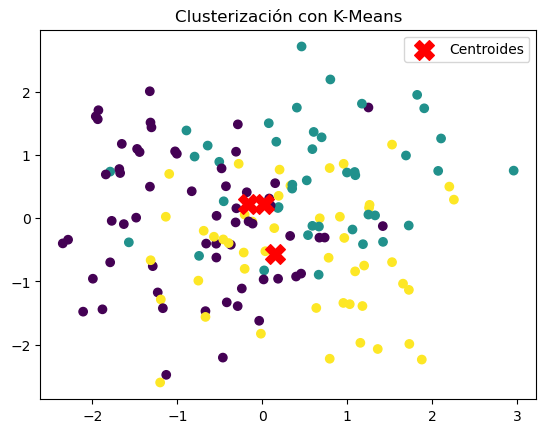

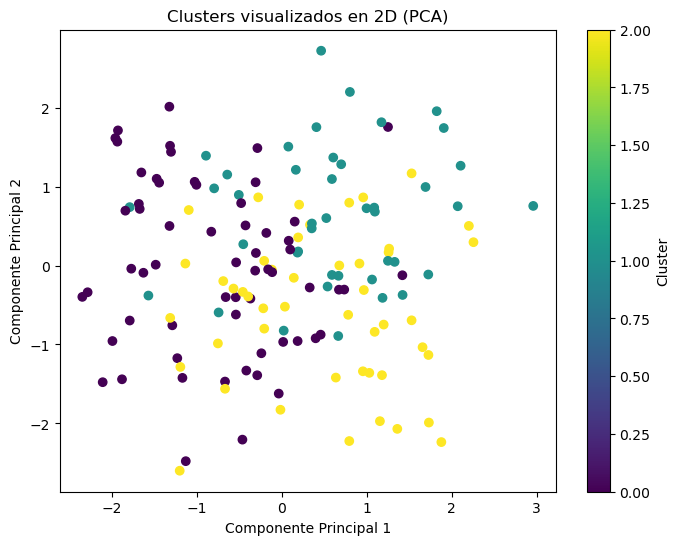

In [6]:


print('Varianza explicada por cada componente:', pca.explained_variance_ratio_)

# Graficar resultados
plt.scatter(df['pca1'], df['pca2'], c=df['cluster'], cmap='viridis')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=200, c='red', marker='X', label='Centroides')
plt.title("Clusterización con K-Means")
plt.legend()
plt.show()


# Visualización de clusters en 2D
plt.figure(figsize=(8,6))
plt.scatter(df['pca1'], df['pca2'], c=df['cluster'], cmap='viridis')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.title('Clusters visualizados en 2D (PCA)')
plt.colorbar(label='Cluster')
plt.show()

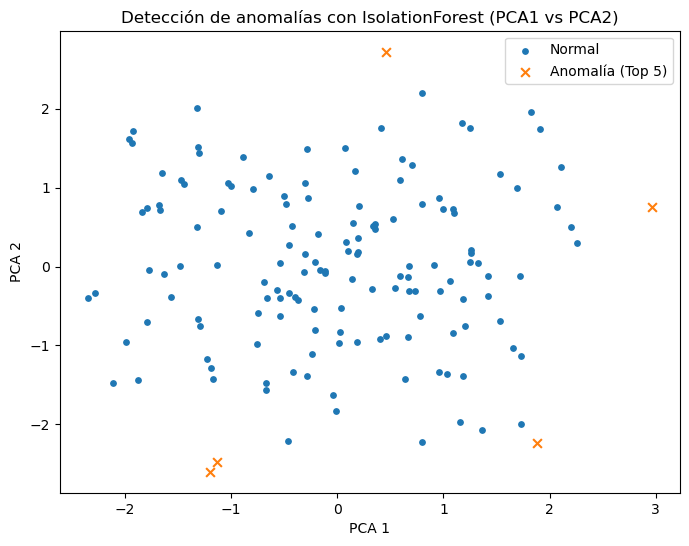

,reproducciones_diarias,min_escucha_promedio,saltos_por_dia,artistas_distintos,dias_activo_mes,likes_dados,dispositivos_usados,cluster,pca1,pca2,score_iso,anomalía_iso
21,17,3.30,5,36,5,10.0,3,0,-1.130117,-2.477794,-0.608005,True
97,29,3.65,11,21,7,7.0,3,2,1.879210,-2.236124,-0.631294,True
115,13,3.55,4,6,9,12.0,3,2,-1.201754,-2.598828,-0.637605,True
134,37,3.25,6,3,27,3.0,2,1,2.961154,0.754943,-0.663428,True
144,41,3.23,3,11,29,12.0,1,1,0.463705,2.720497,-0.674400,True


In [7]:
# 5. Detección de anomalías
from sklearn.ensemble import IsolationForest
# Se importa el algoritmo Isolation Forest, que pertenece a los modelos de conjunto (ensemble models). Es muy eficiente para detectar valores atípicos.

## Crear datos artificiales con algunas anomalías
#rng = df[[df['pca1'], df['pca2']]]
#X_normal = rng.normal(0, 0.5, size=(100, 2))
#X_outliers = rng.uniform(low=-4, high=4, size=(10, 2))
#X_total = np.vstack([X_normal, X_outliers])
#
## Modelo de detección de anomalías
#modelo_iso = IsolationForest(contamination=0.1, random_state=42)
#modelo_iso.fit(X_total)
#preds = modelo_iso.predict(X_total)
## Graficar: -1 = anomalía, 1 = normal
#plt.scatter(X_total[:, 0], X_total[:, 1], c=preds, cmap='coolwarm', edgecolors='k')
#plt.title("Detección de Anomalías con Isolation Forest")
#plt.show()
#
#
#



X = df[['pca1','pca2']].to_numpy()

# Entrenar IsolationForest
iso = IsolationForest(random_state=42)
iso.fit(X)

# Puntajes: menor = más anómalo
df['score_iso'] = iso.score_samples(X)

# Marcar exactamente 5 anomalías más fuertes
df['anomalía_iso'] = False
idx_top5 = df['score_iso'].nsmallest(5).index
df.loc[idx_top5, 'anomalía_iso'] = True

# Gráfico simple
normales = df[~df['anomalía_iso']]
anomalias = df[df['anomalía_iso']]
plt.figure(figsize=(8,6))
plt.scatter(normales['pca1'], normales['pca2'], s=15, label='Normal')
plt.scatter(anomalias['pca1'], anomalias['pca2'], s=40, marker='x', label='Anomalía (Top 5)')
plt.title('Detección de anomalías con IsolationForest (PCA1 vs PCA2)')
plt.xlabel('PCA 1'); plt.ylabel('PCA 2')
plt.legend(); plt.show()

# Vista rápida
df[df['anomalía_iso']].head()

In [8]:
# 5. Detección de anomalías
from scipy.spatial.distance import cdist

# Calcular distancias de cada punto a su centroide
distances = cdist(df_scaled, kmeans.cluster_centers_)
df['dist_centroide'] = [distances[i, cluster] for i, cluster in enumerate(df['cluster'])]

# Marcar top 5 distancias como anomalías
df['anomalía'] = False
df.loc[df['dist_centroide'].nlargest(5).index, 'anomalía'] = True

df[['cluster', 'dist_centroide', 'anomalía']].head(10)

,cluster,dist_centroide,anomalía
0,1,2.160456,False
1,1,2.114644,False
2,2,2.932409,False
3,2,2.188598,False
4,1,2.230459,False
5,0,2.083385,False
6,0,2.180130,False
7,1,1.466124,False
8,2,1.604082,False
9,2,1.820041,False


In [9]:
df

,reproducciones_diarias,min_escucha_promedio,saltos_por_dia,artistas_distintos,dias_activo_mes,likes_dados,dispositivos_usados,cluster,pca1,pca2,score_iso,anomalía_iso,dist_centroide,anomalía
0,28,3.78,6,30,30,11.0,3,1,0.193217,0.178266,-0.397507,False,2.160456,False
1,34,2.88,5,4,29,6.0,1,1,1.907893,1.741596,-0.533160,False,2.114644,False
2,23,3.29,2,8,14,5.0,1,2,0.142056,-0.155391,-0.400152,False,2.932409,False
3,32,3.01,3,11,12,8.0,1,2,0.332289,0.516769,-0.405152,False,2.188598,False
4,36,2.91,5,35,28,8.0,1,1,0.802497,2.198477,-0.573873,False,2.230459,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,28,4.22,7,28,25,6.0,1,2,0.794439,0.795843,-0.428820,False,2.378968,False
146,29,5.00,2,11,24,9.0,2,1,-0.453262,0.269716,-0.424213,False,2.449142,False
147,41,3.57,5,17,10,13.0,2,2,0.193356,0.355981,-0.408712,False,2.623007,False
148,24,5.13,10,12,26,6.0,2,2,1.528877,-0.693863,-0.489780,False,3.166890,False


## 6. Reflexión final
Los hallazgos más útiles para el equipo de marketing podrían incluir:
- Identificación de grupos de usuarios con patrones de escucha similares.
- Reconocimiento de usuarios con comportamientos atípicos (posibles bots o usuarios muy fieles).
- Uso de PCA para visualizar y comprender los principales ejes de variabilidad en la interacción musical.

La segmentación permitiría crear campañas personalizadas, por ejemplo:
- Promociones específicas para heavy users.
- Recomendaciones de artistas para usuarios con gustos similares.
- Acciones para retener a usuarios con baja actividad.